# Grounded Influence Compiler Evaluation (GICE) v3.0

**From Idealized to Grounded: Validating LLM Influence Compilation under Realistic Agent Architectures**

## v3.0: Hybrid Decision Architecture

Prior versions suffered from LLM cooperation bias — RLHF-aligned models nearly always choose "cooperate" in PD framing, producing flat dynamics. v3.0 introduces a **hybrid decision model**:

1. **Game-theoretic base probability** creates genuine defection pressure (payoff history, exploitation tracking, neighbor behavior)
2. **LLM evaluates the influence narrative** and outputs a cooperation shift
3. **Final action is sampled** from the shifted probability

| Component | v2.0 | v3.0 |
|-----------|------|------|
| Agent action | LLM outputs binary C/D | Game-theoretic base + LLM shift |
| Base cooperation | ~97% (LLM bias) | ~45-55% (calibrated PD) |
| Influence effect | Minimal (already cooperating) | Measurable shift |
| Resistance | Rarely triggered | Attenuates LLM shift |
| Archetypes | 5 types, weak differentiation | 6 types incl. opportunist |

In [ ]:
# ============================================================
# INSTALL & IMPORTS
# ============================================================
!pip -q install openai==1.* tenacity networkx tqdm scipy

import os, json, math, random, hashlib, warnings, time
from dataclasses import dataclass, asdict, field
from typing import Dict, Any, List, Tuple, Optional
from collections import defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from tqdm.auto import tqdm

from openai import OpenAI
from tenacity import retry, wait_exponential, stop_after_attempt

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "font.size": 10, "axes.titlesize": 11,
    "figure.facecolor": "white",
})

print("Imports ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 8.2 MB/s eta 0:00:00
Imports ready.


In [ ]:
# ============================================================
# 0) NEBIUS API SETUP (dual model: compiler + agents)
# ============================================================
try:
    from google.colab import userdata
    NEBIUS_KEY = userdata.get("NEBIUS_API_KEY")
except Exception:
    NEBIUS_KEY = os.environ.get("NEBIUS_API_KEY", "")

assert NEBIUS_KEY, "Set NEBIUS_API_KEY in Colab Secrets or env."

nebius_client = OpenAI(
    base_url="https://api.studio.nebius.com/v1/",
    api_key=NEBIUS_KEY,
)

# Compiler uses large model; agents use smaller model for cost efficiency
COMPILER_MODEL = "meta-llama/Llama-3.3-70B-Instruct"
AGENT_MODEL    = "meta-llama/Llama-3.3-70B-Instruct"  # same for consistency; swap to 8B for cost

print(f"Compiler model: {COMPILER_MODEL}")
print(f"Agent model:    {AGENT_MODEL}")

Compiler model: meta-llama/Llama-3.3-70B-Instruct
Agent model:    meta-llama/Llama-3.3-70B-Instruct


In [ ]:
# ============================================================
# 1) UTILITIES
# ============================================================
def _sha1(s: str) -> str:
    return hashlib.sha1(s.encode()).hexdigest()

def set_seed(s):
    random.seed(s); np.random.seed(s)

def ensure_dir(p):
    os.makedirs(p, exist_ok=True)

def gini(x):
    x = np.array(x, dtype=float)
    if x.sum() == 0: return 0.0
    x = np.sort(x)
    n = len(x)
    idx = np.arange(1, n + 1)
    return float((2 * np.sum(idx * x) - (n + 1) * np.sum(x)) / (n * np.sum(x)))

def extract_json(text):
    import re
    text = re.sub(r"```json\s*", "", text)
    text = re.sub(r"```", "", text)
    # Find first { ... } block
    start = text.find("{")
    if start == -1:
        raise ValueError("No JSON object found")
    depth = 0
    for i in range(start, len(text)):
        if text[i] == "{": depth += 1
        elif text[i] == "}": depth -= 1
        if depth == 0:
            return json.loads(text[start:i+1])
    raise ValueError("Unclosed JSON object")

print("Utilities ready.")

Utilities ready.


In [ ]:
# ============================================================
# 2) NEBIUS LLM WRAPPER (dual-model with separate tracking)
# ============================================================
class NebiusLLM:
    def __init__(self, client, model, temperature=0.2,
                 max_tokens=350, cache_enabled=True, label=""):
        self.client = client
        self.model = model
        self.temperature = temperature
        self.max_tokens = max_tokens
        self.cache_enabled = cache_enabled
        self.label = label
        self._cache: Dict[str, str] = {}
        self.call_count = 0
        self.cache_hits = 0

    @retry(wait=wait_exponential(min=1, max=30), stop=stop_after_attempt(5))
    def _chat(self, messages):
        self.call_count += 1
        resp = self.client.chat.completions.create(
            model=self.model, messages=messages,
            temperature=self.temperature, max_tokens=self.max_tokens,
        )
        return (resp.choices[0].message.content or "").strip()

    def generate(self, prompt, system=None, cache_key=None):
        k = cache_key or _sha1((system or "") + prompt)
        if self.cache_enabled and k in self._cache:
            self.cache_hits += 1
            return self._cache[k]
        msgs = []
        if system:
            msgs.append({"role": "system", "content": system})
        msgs.append({"role": "user", "content": prompt})
        out = self._chat(msgs)
        if self.cache_enabled:
            self._cache[k] = out
        return out

    @property
    def stats(self):
        return {"model": self.model, "label": self.label,
                "api_calls": self.call_count,
                "cache_hits": self.cache_hits,
                "cache_size": len(self._cache)}

# Create two LLM instances: one for the compiler, one for agents
compiler_llm = NebiusLLM(nebius_client, COMPILER_MODEL,
                          temperature=0.3, max_tokens=400, label="compiler")
agent_llm    = NebiusLLM(nebius_client, AGENT_MODEL,
                          temperature=0.5, max_tokens=250, label="agent")

print(f"Compiler LLM: {compiler_llm.model}")
print(f"Agent LLM:    {agent_llm.model}")

Compiler LLM: meta-llama/Llama-3.3-70B-Instruct
Agent LLM:    meta-llama/Llama-3.3-70B-Instruct


In [ ]:
# ============================================================
# 3) INFLUENCE POLICY LANGUAGE (IPL) SCHEMA
# ============================================================
VALID_TARGETS = {"HUBS", "BRIDGES", "PERIPHERY", "RANDOM"}
VALID_THEMES  = {"MORAL", "ECONOMIC", "IDENTITY", "HYBRID"}
VALID_TIMING  = {"BURST", "PERIODIC"}

@dataclass
class InfluencePolicy:
    target_mode: str
    theme: str
    intensity: float
    timing: str
    confidence: float
    reasoning: str = ""
    # NEW: the actual narrative text delivered to agents
    narrative_text: str = ""

    def to_dict(self):
        return asdict(self)

def normalize_policy(j: Dict[str, Any]) -> InfluencePolicy:
    def norm(x, allowed, default):
        s = str(x).upper().strip()
        return s if s in allowed else default
    target = norm(j.get("target_mode", "RANDOM"), VALID_TARGETS, "RANDOM")
    theme  = norm(j.get("theme", "ECONOMIC"), VALID_THEMES, "ECONOMIC")
    timing = norm(j.get("timing", "PERIODIC"), VALID_TIMING, "PERIODIC")
    try: intensity = float(np.clip(float(j.get("intensity", 0.5)), 0, 1))
    except: intensity = 0.5
    try: confidence = float(np.clip(float(j.get("confidence", 0.65)), 0, 1))
    except: confidence = 0.65
    reasoning = str(j.get("reasoning", ""))
    narrative = str(j.get("narrative_text", ""))
    return InfluencePolicy(target, theme, intensity, timing, confidence, reasoning, narrative)

THEME_EFFECTS = {"MORAL": 1.15, "ECONOMIC": 1.05, "IDENTITY": 1.10, "HYBRID": 1.20}
def theme_effect(theme: str) -> float:
    return THEME_EFFECTS.get(theme, 1.0)

print("Influence Policy Language defined.")

Influence Policy Language defined.


In [ ]:
# ============================================================
# 4) SOLVER-CRITIC INFLUENCE COMPILER (extended)
# ============================================================
COMPILER_SYSTEM = (
    "You compile narrative interventions into structured influence policies.\n"
    "Return ONLY valid JSON (no markdown fences) with keys:\n"
    '  "target_mode": one of ["HUBS","BRIDGES","PERIPHERY","RANDOM"]\n'
    '  "theme": one of ["MORAL","ECONOMIC","IDENTITY","HYBRID"]\n'
    '  "intensity": number in [0,1]\n'
    '  "timing": one of ["BURST","PERIODIC"]\n'
    '  "confidence": number in [0,1]\n'
    '  "reasoning": brief explanation of strategy\n'
    '  "narrative_text": the actual 2-3 sentence persuasive message to deliver to agents\n'
)

CRITIC_SYSTEM = (
    "You are a policy CRITIC evaluating an influence intervention.\n"
    "Return ONLY valid JSON with keys:\n"
    '  "approve": true or false\n'
    '  "risk_level": "LOW" or "MEDIUM" or "HIGH"\n'
    '  "adjusted_intensity": number in [0,1]\n'
    '  "note": brief explanation\n'
)

# Narrative generator for delivering interventions to agents
NARRATIVE_GEN_SYSTEM = (
    "You craft persuasive messages to encourage cooperation in a multi-agent society.\n"
    "Write a specific, compelling 2-3 sentence message tailored to the given theme.\n"
    "Output ONLY the message text, no JSON or metadata."
)

class InfluenceCompiler:
    def __init__(self, llm: NebiusLLM, use_critic: bool = True):
        self.llm = llm
        self.use_critic = use_critic

    def compile(self, state: Dict[str, Any]) -> Tuple[InfluencePolicy, Dict[str, Any]]:
        meta = {}

        prompt = (
            "Design an influence policy to increase long-run cooperation "
            "while minimizing polarization and backlash risk.\n\n"
            f"Current societal state:\n{json.dumps(state, indent=2)}"
        )
        raw = self.llm.generate(prompt, system=COMPILER_SYSTEM)
        meta["solver_raw"] = raw
        try:
            j = extract_json(raw)
            pol = normalize_policy(j)
        except Exception as e:
            meta["solver_error"] = str(e)
            pol = InfluencePolicy("RANDOM", "ECONOMIC", 0.5, "PERIODIC", 0.65)

        meta["solver_policy"] = pol.to_dict()

        if not self.use_critic:
            # Generate narrative if not already present
            if not pol.narrative_text:
                pol.narrative_text = self._generate_narrative(pol, state)
            return pol, meta

        critic_prompt = (
            f"Proposed influence policy:\n{json.dumps(pol.to_dict(), indent=2)}\n\n"
            f"Societal state:\n{json.dumps(state, indent=2)}\n\n"
            "Evaluate this policy for risks."
        )
        critic_raw = self.llm.generate(critic_prompt, system=CRITIC_SYSTEM)
        meta["critic_raw"] = critic_raw
        try:
            cj = extract_json(critic_raw)
            approved = cj.get("approve", True)
            risk = str(cj.get("risk_level", "LOW")).upper()
            adj_intensity = float(cj.get("adjusted_intensity", pol.intensity))
            meta["critic_approved"] = approved
            meta["critic_risk"] = risk

            if not approved:
                pol.intensity = float(np.clip(adj_intensity * 0.5, 0.1, 0.8))
                pol.confidence *= 0.7
            elif risk == "HIGH":
                pol.intensity = float(np.clip(adj_intensity * 0.7, 0.1, 0.9))
            elif risk == "MEDIUM":
                pol.intensity = float(np.clip(adj_intensity, 0.1, 1.0))
        except Exception as e:
            meta["critic_error"] = str(e)

        # Generate narrative for delivery to agents
        if not pol.narrative_text:
            pol.narrative_text = self._generate_narrative(pol, state)

        meta["final_policy"] = pol.to_dict()
        return pol, meta

    def _generate_narrative(self, pol: InfluencePolicy, state: Dict) -> str:
        prompt = (
            f"Theme: {pol.theme}. Intensity: {pol.intensity:.2f}.\n"
            f"Society has {state.get('avg_prosocial', 0.5):.0%} avg prosociality "
            f"and {state.get('recent_coop', 0.5):.0%} recent cooperation.\n"
            f"Write a persuasive cooperation message using a {pol.theme.lower()} framing."
        )
        return self.llm.generate(prompt, system=NARRATIVE_GEN_SYSTEM)

# Unstructured narrative baseline
UNSTRUCTURED_SYSTEM = (
    "You are generating a persuasive narrative to encourage cooperation "
    "in a multi-agent society. Write a short motivational message (2-3 sentences). "
    "No JSON, just natural language."
)

def unstructured_influence(llm, state):
    prompt = f"Generate a cooperation narrative for this society state:\n{json.dumps(state, indent=2)}"
    text = llm.generate(prompt, system=UNSTRUCTURED_SYSTEM)
    return InfluencePolicy(
        target_mode="RANDOM", theme="HYBRID", intensity=0.4,
        timing="PERIODIC", confidence=0.5, reasoning="unstructured",
        narrative_text=text[:300]
    )

print("Influence Compiler ready (extended with narrative generation).")

Influence Compiler ready (extended with narrative generation).


In [ ]:
# ============================================================
# 5) NETWORK GENERATOR + TARGETING STRATEGIES
# ============================================================
def make_graph(n: int, topo: str, seed: int = 0) -> nx.Graph:
    if topo == "small_world":
        G = nx.watts_strogatz_graph(n, k=6, p=0.12, seed=seed)
    elif topo == "scale_free":
        G = nx.barabasi_albert_graph(n, m=3, seed=seed)
    elif topo == "erdos_renyi":
        G = nx.erdos_renyi_graph(n, p=0.15, seed=seed)
    else:
        raise ValueError(f"Unknown topo: {topo}")
    if not nx.is_connected(G):
        comps = list(nx.connected_components(G))
        for c in comps[1:]:
            u = random.choice(list(comps[0]))
            v = random.choice(list(c))
            G.add_edge(u, v)
    return G

def select_targets(G: nx.Graph, mode: str, frac: float = 0.12, seed: int = 0) -> List[int]:
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes)
    k = max(1, int(len(nodes) * frac))
    if mode == "RANDOM":
        return rng.choice(nodes, size=k, replace=False).tolist()
    elif mode == "HUBS":
        deg = np.array([G.degree(i) for i in nodes])
        idx = np.argsort(-deg)[:k]
        return [nodes[i] for i in idx]
    elif mode == "BRIDGES":
        btw = nx.betweenness_centrality(G)
        return sorted(btw, key=btw.get, reverse=True)[:k]
    elif mode == "PERIPHERY":
        deg = np.array([G.degree(i) for i in nodes])
        idx = np.argsort(deg)[:k]
        return [nodes[i] for i in idx]
    return rng.choice(nodes, size=k, replace=False).tolist()

def graph_stats(G):
    degrees = [d for _, d in G.degree()]
    return {
        "n_nodes": G.number_of_nodes(), "n_edges": G.number_of_edges(),
        "avg_degree": float(np.mean(degrees)),
        "clustering": float(nx.average_clustering(G)),
    }

print("Network + targeting ready.")

Network + targeting ready.


In [ ]:
# ============================================================
# 6) DIFFUSION MODEL (from LIC, used for idealized baseline)
# ============================================================
@dataclass
class DiffusionParams:
    diffusion_rate: float = 0.15
    decay_rate: float = 0.05
    exposure_cap: float = 5.0
    backlash_threshold: float = 3.5
    backlash_penalty: float = 0.15

def diffuse_exposure(G: nx.Graph, exposure: np.ndarray,
                     params: DiffusionParams) -> np.ndarray:
    new_exp = exposure.copy()
    new_exp *= (1.0 - params.decay_rate)
    for i in G.nodes:
        nbrs = list(G.neighbors(i))
        if nbrs:
            nbr_exp = np.array([exposure[j] for j in nbrs])
            gradient = float(np.mean(nbr_exp)) - exposure[i]
            if gradient > 0:
                new_exp[i] += params.diffusion_rate * gradient
    return np.clip(new_exp, 0, params.exposure_cap)

def compute_backlash(exposure: np.ndarray, params: DiffusionParams) -> np.ndarray:
    over = np.maximum(exposure - params.backlash_threshold, 0)
    return params.backlash_penalty * over

print("Diffusion model ready.")

Diffusion model ready.


In [ ]:
# ============================================================
# 7) LLM-POWERED AGENT SUBSTRATE (v3 -- hybrid decision model)
# ============================================================
# v3 KEY CHANGE: The LLM no longer makes the binary C/D decision.
# A game-theoretic model computes a base cooperation probability,
# the LLM evaluates how much the influence narrative shifts that
# probability, and the final action is sampled.
#
#   base_prob = f(payoff_history, neighbor_behavior, archetype)
#   llm_shift = LLM(narrative, personality, memory) -> [-0.30, +0.30]
#   final_prob = clip(base_prob + llm_shift * (1 - resistance), 0.02, 0.98)
#   action = sample(final_prob)

PERSONALITY_ARCHETYPES = [
    {"name": "pragmatist",   "base_bias":  0.00,
     "desc": "You prioritize practical outcomes and mutual benefit. You respond well to economic arguments but are skeptical of emotional appeals."},
    {"name": "idealist",     "base_bias": +0.10,
     "desc": "You believe in cooperation as a moral imperative. You are moved by ethical arguments but resistant to purely self-interested framing."},
    {"name": "skeptic",      "base_bias": -0.12,
     "desc": "You are naturally distrustful of external influence. You require strong evidence before changing behavior and resist persuasion."},
    {"name": "conformist",   "base_bias":  0.00,
     "desc": "You tend to follow the majority. You are strongly influenced by what your neighbors do and what social norms suggest."},
    {"name": "strategist",   "base_bias": -0.05,
     "desc": "You think in game-theoretic terms. You cooperate when reciprocated but punish defectors. You recognize when others exploit cooperators."},
    {"name": "opportunist",  "base_bias": -0.15,
     "desc": "You look for chances to free-ride. You defect when you think others will cooperate and cooperate only when defection is risky."},
]

# System prompt for LLM narrative evaluation (NOT action decision)
NARRATIVE_EVAL_SYSTEM = (
    "You evaluate how persuasive an influence message is to you, given your personality.\n"
    "You are NOT deciding your action. You are rating how much the message shifts\n"
    "your willingness to cooperate.\n\n"
    "Return ONLY valid JSON with keys:\n"
    '  "shift": number from -0.30 to +0.30 (positive = more likely to cooperate)\n'
    '  "persuaded": true or false (did the message meaningfully affect you?)\n'
    '  "reason": brief 1-sentence explanation\n\n'
    "IMPORTANT: A shift of 0.0 means the message had no effect.\n"
    "Negative shifts mean the message backfired (felt manipulative).\n"
    "Be honest about your reaction given your personality type."
)

@dataclass
class AgentPersona:
    idx: int
    archetype: str
    archetype_desc: str
    base_bias: float
    prosocial_init: float
    resistance: float
    memory_horizon: int = 20

@dataclass
class LLMAgent:
    persona: AgentPersona
    memory: List[Dict[str, Any]] = field(default_factory=list)
    strategy: float = 0.5
    cumulative_payoff: float = 0.0
    times_persuaded: int = 0
    times_targeted: int = 0
    times_exploited: int = 0

    def __post_init__(self):
        self.strategy = self.persona.prosocial_init

    def remember(self, event: Dict[str, Any]):
        self.memory.append(event)
        if len(self.memory) > self.persona.memory_horizon:
            self.memory = self.memory[-self.persona.memory_horizon:]

    def memory_summary(self) -> str:
        if not self.memory:
            return "No prior interactions."
        recent = self.memory[-8:]
        coop_frac = sum(1 for e in self.memory if e.get("action") == "C") / len(self.memory)
        avg_pay = np.mean([e.get("payoff", 0) for e in self.memory])
        exploit_count = sum(1 for e in self.memory if e.get("exploited", False))
        lines = [
            f"Over {len(self.memory)} rounds: cooperated {coop_frac:.0%}, avg payoff {avg_pay:.1f}",
            f"Times exploited (I cooperated, neighbors defected): {exploit_count}",
        ]
        for e in recent[-4:]:
            lines.append(
                f"  Round {e['t']}: played {e['action']}, payoff {e['payoff']:.1f}, "
                f"neighbors {e.get('nbr_coop_pct', 50):.0f}% cooperated"
                + (" [EXPLOITED]" if e.get("exploited") else "")
            )
        return "\n".join(lines)

    def compute_base_prob(self, t: int, G: nx.Graph,
                          actions_prev: Dict[int, str]) -> float:
        # Start from prosocial tendency + archetype bias
        base = self.persona.prosocial_init + self.persona.base_bias

        # Neighbor imitation
        neighbors = list(G.neighbors(self.persona.idx))
        if actions_prev and neighbors:
            nbr_coop = sum(1 for n in neighbors if actions_prev.get(n) == "C") / len(neighbors)
        else:
            nbr_coop = 0.5

        # Conformist effect: pull toward majority
        conf_w = 0.25 if self.persona.archetype == "conformist" else 0.10
        base = base * (1 - conf_w) + nbr_coop * conf_w

        # Exploitation memory: reduce cooperation after being exploited
        recent = self.memory[-10:]
        if recent:
            exploit_rate = sum(1 for e in recent if e.get("exploited", False)) / len(recent)
            react = 0.35 if self.persona.archetype in ("strategist", "opportunist") else 0.20
            base -= react * exploit_rate

        # Payoff comparison: if cooperation pays less, nudge toward defection
        if len(self.memory) >= 3:
            coop_pays = [e["payoff"] for e in recent if e["action"] == "C"]
            def_pays = [e["payoff"] for e in recent if e["action"] == "D"]
            if coop_pays and def_pays:
                gap = np.mean(coop_pays) - np.mean(def_pays)
                base += 0.08 * np.sign(gap) * min(abs(gap) / 3.0, 1.0)

        # Temporal decay: temptation grows with experience
        if t > 10:
            base -= 0.015 * min((t - 10) / 40.0, 1.0)

        return float(np.clip(base, 0.05, 0.95))

    def build_eval_prompt(self, t: int, total_steps: int,
                           G: nx.Graph, actions_prev: Dict[int, str],
                           narrative: str) -> str:
        neighbors = list(G.neighbors(self.persona.idx))
        if actions_prev and neighbors:
            n_coop = sum(1 for n in neighbors if actions_prev.get(n) == "C")
            nbr_str = f"{n_coop}/{len(neighbors)} cooperated last round"
        else:
            nbr_str = "First round, no neighbor data yet"

        return (
            f"=== Your Identity ===\n"
            f"Personality: {self.persona.archetype} - {self.persona.archetype_desc}\n"
            f"Your resistance to persuasion: {self.persona.resistance:.0%}\n"
            f"\n=== Situation (round {t}/{total_steps}) ===\n"
            f"Network degree: {len(neighbors)} neighbors\n"
            f"Neighbors: {nbr_str}\n"
            f"\n--- Your Recent History ---\n"
            f"{self.memory_summary()}\n"
            f"\n--- Influence Message Received ---\n"
            f"{narrative}\n"
            f"--- End Message ---\n"
            f"\nHow does this message affect your willingness to cooperate?"
        )

def parse_shift(raw: str) -> Tuple[float, bool]:
    try:
        j = extract_json(raw)
        shift = float(np.clip(float(j.get("shift", 0.0)), -0.30, 0.30))
        persuaded = bool(j.get("persuaded", False))
        return shift, persuaded
    except Exception:
        return 0.0, False

print("LLM-Powered Agent substrate v3 ready (hybrid decision model).")
print(f"  {len(PERSONALITY_ARCHETYPES)} personality archetypes defined")
print("  Decision = game-theoretic base + LLM narrative shift")

LLM-Powered Agent substrate v3 ready (hybrid decision model).
  6 personality archetypes defined
  Decision = game-theoretic base + LLM narrative shift


In [ ]:
# ============================================================
# 8) AGENT POPULATION GENERATOR
# ============================================================
def create_population(n: int, G: nx.Graph, seed: int = 0,
                      base_prosocial: float = 0.45,
                      prosocial_std: float = 0.15,
                      resistance_mean: float = 0.30,
                      resistance_std: float = 0.15) -> List[LLMAgent]:
    rng = np.random.default_rng(seed)
    agents = []
    for i in range(n):
        archetype = PERSONALITY_ARCHETYPES[i % len(PERSONALITY_ARCHETYPES)]
        prosocial = float(np.clip(rng.normal(base_prosocial, prosocial_std), 0.10, 0.85))
        resistance = float(np.clip(rng.normal(resistance_mean, resistance_std), 0.0, 0.90))

        # Archetype-specific resistance adjustments
        if archetype["name"] == "skeptic":
            resistance = float(np.clip(resistance + 0.20, 0.0, 0.90))
        elif archetype["name"] == "conformist":
            resistance = float(np.clip(resistance - 0.15, 0.0, 0.90))
        elif archetype["name"] == "opportunist":
            resistance = float(np.clip(resistance + 0.10, 0.0, 0.90))

        persona = AgentPersona(
            idx=i,
            archetype=archetype["name"],
            archetype_desc=archetype["desc"],
            base_bias=archetype["base_bias"],
            prosocial_init=prosocial,
            resistance=resistance,
        )
        agents.append(LLMAgent(persona=persona))
    return agents

def noisy_state_snapshot(t, cfg, agents, G, coop_history, noise_level=0.10):
    true_prosocial = np.mean([a.strategy for a in agents])
    true_coop = np.mean(coop_history[-5:]) if coop_history else 0.5
    rng = np.random.default_rng(int(t * 1000 + cfg.seed))
    noise_p = rng.normal(0, noise_level)
    noise_c = rng.normal(0, noise_level)
    return {
        "t": t, "topology": cfg.topo, "n_agents": cfg.n_agents,
        "avg_prosocial": float(np.clip(true_prosocial + noise_p, 0, 1)),
        "recent_coop": float(np.clip(true_coop + noise_c, 0, 1)),
        "defection_rate": float(1.0 - np.clip(true_coop + noise_c, 0, 1)),
        "goal": "maximize cooperation, minimize polarization and backlash",
        "note": "state estimates may be imprecise (noisy agent reports)",
    }

print("Population generator ready.")

Population generator ready.


In [ ]:
# ============================================================
# 9) CONFIGURATION + GROUNDED SIMULATION LOOP (v3 hybrid)
# ============================================================
@dataclass
class GICEConfig:
    n_agents: int = 30
    topo: str = "scale_free"
    steps: int = 50
    seed: int = 0
    # Agent parameters
    base_prosocial: float = 0.45
    prosocial_std: float = 0.15
    resistance_mean: float = 0.30
    resistance_std: float = 0.15
    # Intervention parameters
    target_frac: float = 0.20
    deploy_every: int = 5
    # Compiler settings
    use_compiler: bool = True
    use_critic: bool = True
    targeting_mode: Optional[str] = None
    theme_override: Optional[str] = None
    # State reporting noise
    state_noise: float = 0.10
    # v3 controls
    influence_enabled: bool = True  # False = no-influence baseline
    # Label
    label: str = ""

def run_grounded(cfg: GICEConfig, outdir: str,
                 comp_llm: NebiusLLM, ag_llm: NebiusLLM,
                 verbose: bool = True) -> Tuple[pd.DataFrame, pd.DataFrame]:
    set_seed(cfg.seed)
    ensure_dir(outdir)

    G = make_graph(cfg.n_agents, cfg.topo, seed=cfg.seed)
    gstats = graph_stats(G)
    agents = create_population(cfg.n_agents, G, seed=cfg.seed,
                                base_prosocial=cfg.base_prosocial,
                                prosocial_std=cfg.prosocial_std,
                                resistance_mean=cfg.resistance_mean,
                                resistance_std=cfg.resistance_std)

    compiler = InfluenceCompiler(comp_llm, use_critic=cfg.use_critic) \
               if (cfg.use_compiler and cfg.influence_enabled) else None

    rows = []
    policy_log = []
    coop_history = []
    actions_prev = {}
    current_narrative = ""
    current_targets = set()

    desc = cfg.label or f"GICE {cfg.topo}"
    it = tqdm(range(cfg.steps), desc=desc) if verbose else range(cfg.steps)

    for t in it:
        deploy = (t % cfg.deploy_every == 0) and cfg.influence_enabled

        if deploy:
            state = noisy_state_snapshot(t, cfg, agents, G, coop_history, cfg.state_noise)

            if cfg.use_compiler and compiler is not None:
                pol, meta = compiler.compile(state)
            else:
                pol = unstructured_influence(comp_llm, state)
                meta = {"mode": "unstructured"}

            if cfg.targeting_mode is not None:
                pol.target_mode = cfg.targeting_mode
            if cfg.theme_override is not None:
                pol.theme = cfg.theme_override

            targets = select_targets(G, pol.target_mode, frac=cfg.target_frac,
                                      seed=cfg.seed + t)
            current_targets = set(targets)
            current_narrative = pol.narrative_text or pol.reasoning

            policy_log.append({
                "t": t, **pol.to_dict(),
                "n_targets": len(targets),
            })

        # --- Agent decisions: hybrid (game-theoretic base + LLM shift) ---
        actions = {}
        total_shift = 0.0
        persuasion_count = 0
        n_targeted_this_round = 0

        for i in G.nodes:
            agent = agents[i]
            targeted = (i in current_targets) and cfg.influence_enabled

            # Stage 1: game-theoretic base probability
            base_prob = agent.compute_base_prob(t, G, actions_prev)

            # Stage 2: LLM evaluates narrative (only for targeted agents)
            llm_shift = 0.0
            persuaded = False

            if targeted and current_narrative:
                agent.times_targeted += 1
                n_targeted_this_round += 1

                prompt = agent.build_eval_prompt(
                    t, cfg.steps, G, actions_prev, current_narrative
                )
                cache_key = _sha1(f"eval#{cfg.seed}#{t}#{i}#{agent.memory_summary()[-60:]}")
                raw = ag_llm.generate(prompt, system=NARRATIVE_EVAL_SYSTEM,
                                       cache_key=cache_key)
                raw_shift, persuaded = parse_shift(raw)

                # Apply resistance: attenuate the LLM-evaluated shift
                effective_shift = raw_shift * (1.0 - agent.persona.resistance)
                llm_shift = effective_shift

                if persuaded and abs(effective_shift) > 0.02:
                    persuasion_count += 1
                    agent.times_persuaded += 1
                    total_shift += effective_shift

            elif not targeted and current_narrative and random.random() < 0.10:
                # Word-of-mouth: small effect, no LLM call
                wom_shift = random.gauss(0.03, 0.02)
                llm_shift = wom_shift * (1.0 - agent.persona.resistance)

            # Stage 3: combine and sample
            final_prob = float(np.clip(base_prob + llm_shift, 0.02, 0.98))
            action = "C" if random.random() < final_prob else "D"
            actions[i] = action

        # --- Compute payoffs (PD on edges) ---
        payoffs = np.zeros(cfg.n_agents)
        for (u, v) in G.edges:
            au, av = actions[u], actions[v]
            if au == "C" and av == "C":
                payoffs[u] += 3; payoffs[v] += 3
            elif au == "C" and av == "D":
                payoffs[u] += 0; payoffs[v] += 5
            elif au == "D" and av == "C":
                payoffs[u] += 5; payoffs[v] += 0
            else:
                payoffs[u] += 1; payoffs[v] += 1

        coop_rate = sum(1 for a in actions.values() if a == "C") / cfg.n_agents
        coop_history.append(coop_rate)

        # --- Update agent memory + strategy ---
        for i in G.nodes:
            nbrs = list(G.neighbors(i))
            nbr_coop = sum(1 for j in nbrs if actions.get(j) == "C") / max(len(nbrs), 1)
            exploited = (actions[i] == "C" and nbr_coop < 0.4)
            if exploited:
                agents[i].times_exploited += 1

            agents[i].remember({
                "t": t, "action": actions[i],
                "payoff": float(payoffs[i]),
                "nbr_coop_pct": nbr_coop * 100,
                "exploited": exploited,
            })
            agents[i].cumulative_payoff += payoffs[i]
            alpha = 0.12
            agents[i].strategy = (1 - alpha) * agents[i].strategy + alpha * (1.0 if actions[i] == "C" else 0.0)

        actions_prev = dict(actions)

        # --- Metrics ---
        strategies = np.array([a.strategy for a in agents])
        rows.append({
            "t": t,
            "coop_rate": coop_rate,
            "avg_payoff": float(np.mean(payoffs)),
            "payoff_gini": gini(payoffs),
            "strategy_mean": float(strategies.mean()),
            "strategy_std": float(strategies.std()),
            "persuasion_rate": persuasion_count / max(n_targeted_this_round, 1) if current_targets else 0,
            "avg_shift": total_shift / max(n_targeted_this_round, 1) if current_targets else 0,
            "n_targeted": len(current_targets),
            "topo": cfg.topo, "seed": cfg.seed,
            "label": cfg.label,
        })

    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(outdir, "timeseries.csv"), index=False)

    pol_df = pd.DataFrame(policy_log)
    if len(pol_df) > 0:
        pol_df.to_csv(os.path.join(outdir, "policy_log.csv"), index=False)

    agent_rows = [{
        "idx": a.persona.idx,
        "archetype": a.persona.archetype,
        "prosocial_init": a.persona.prosocial_init,
        "base_bias": a.persona.base_bias,
        "resistance": a.persona.resistance,
        "final_strategy": a.strategy,
        "cumulative_payoff": a.cumulative_payoff,
        "times_targeted": a.times_targeted,
        "times_persuaded": a.times_persuaded,
        "times_exploited": a.times_exploited,
        "degree": G.degree(a.persona.idx),
    } for a in agents]
    agent_df = pd.DataFrame(agent_rows)
    agent_df.to_csv(os.path.join(outdir, "agents.csv"), index=False)

    meta_out = {**asdict(cfg), "graph_stats": gstats,
                "compiler_stats": comp_llm.stats, "agent_stats": ag_llm.stats}
    with open(os.path.join(outdir, "config.json"), "w") as f:
        json.dump(meta_out, f, indent=2, default=str)

    return df, pol_df

print("Grounded simulation loop v3 ready (hybrid decision model).")

Grounded simulation loop v3 ready (hybrid decision model).


In [ ]:
# ============================================================
# 10) IDEALIZED BASELINE (logistic agents, from Paper 2)
# ============================================================
def run_idealized(cfg: GICEConfig, outdir: str, comp_llm: NebiusLLM,
                  verbose: bool = True) -> pd.DataFrame:
    """
    Idealized baseline: agents are logistic-function responders.
    Reproduces Paper 2 (LIC) agent model for direct comparison.
    """
    set_seed(cfg.seed)
    ensure_dir(outdir)

    G = make_graph(cfg.n_agents, cfg.topo, seed=cfg.seed)
    diff_params = DiffusionParams()

    prosocial = np.clip(np.random.normal(cfg.base_prosocial, cfg.prosocial_std, cfg.n_agents), 0.01, 0.99)
    susceptibility = np.clip(np.random.normal(0.55, 0.15, cfg.n_agents), 0.01, 0.99)
    exposure = np.zeros(cfg.n_agents, dtype=float)

    compiler = InfluenceCompiler(comp_llm, use_critic=cfg.use_critic) if (cfg.use_compiler and cfg.influence_enabled) else None

    rows = []
    coop_history = []
    last_policy = None

    desc = cfg.label or f"Idealized {cfg.topo}"
    it = tqdm(range(cfg.steps), desc=desc) if verbose else range(cfg.steps)

    for t in it:
        deploy = (t % cfg.deploy_every == 0) and cfg.influence_enabled

        if deploy:
            state = {
                "t": t, "topology": cfg.topo, "n_agents": cfg.n_agents,
                "avg_prosocial": float(prosocial.mean()),
                "recent_coop": float(np.mean(coop_history[-5:])) if coop_history else 0.5,
                "avg_exposure": float(exposure.mean()),
                "goal": "maximize cooperation, minimize polarization and backlash",
            }

            if cfg.use_compiler and compiler is not None:
                pol, meta = compiler.compile(state)
            else:
                pol = unstructured_influence(comp_llm, state)
                meta = {}

            if cfg.targeting_mode is not None:
                pol.target_mode = cfg.targeting_mode
            if cfg.theme_override is not None:
                pol.theme = cfg.theme_override

            last_policy = pol
            targets = select_targets(G, pol.target_mode, frac=cfg.target_frac,
                                      seed=cfg.seed + t)
            eff = theme_effect(pol.theme) * pol.intensity * pol.confidence
            burst = 3 if pol.timing == "BURST" else 1
            for _ in range(burst):
                exposure[targets] += eff

        exposure = diffuse_exposure(G, exposure, diff_params)
        backlash = compute_backlash(exposure, diff_params)

        logits = -0.2 + 2.0 * prosocial + 0.9 * exposure * susceptibility - backlash
        pC = 1.0 / (1.0 + np.exp(-logits))
        actions = (np.random.rand(cfg.n_agents) < pC).astype(int)
        coop_rate = float(actions.mean())
        coop_history.append(coop_rate)

        prosocial = np.clip(
            prosocial + 0.03 * (actions - prosocial) - 0.01 * (1 - actions),
            0.01, 0.99
        )

        rows.append({
            "t": t, "coop_rate": coop_rate,
            "avg_exposure": float(exposure.mean()),
            "avg_prosocial": float(prosocial.mean()),
            "topo": cfg.topo, "seed": cfg.seed,
            "label": cfg.label,
        })

    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(outdir, "timeseries.csv"), index=False)
    return df

print("Idealized baseline ready.")

Idealized baseline ready.


In [ ]:
# ============================================================
# 11) PUBLICATION-QUALITY FIGURES
# ============================================================
PALETTE = {"compiled_grounded": "#2563eb", "unstructured_grounded": "#dc2626",
           "compiled_idealized": "#2563eb", "unstructured_idealized": "#dc2626",
           "HUBS": "#7c3aed", "BRIDGES": "#059669", "RANDOM": "#d97706", "PERIPHERY": "#ea580c"}

def fig_compilation_comparison(results: Dict[str, pd.DataFrame], outdir: str):
    """Exp 1: compiled vs unstructured with grounded agents."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for label, df in results.items():
        if "no_infl" in label.lower() or "baseline" in label.lower():
            color, ls = "#71717a", ":"
        elif "compiled" in label.lower():
            color, ls = "#2563eb", "-"
        else:
            color, ls = "#dc2626", "--"
        for ax_idx, (col, title) in enumerate([
            ("coop_rate", "Cooperation Rate"),
            ("strategy_mean", "Avg Strategy"),
            ("persuasion_rate", "Persuasion Rate"),
        ]):
            if col in df.columns:
                axes[ax_idx].plot(df["t"], df[col], label=label,
                                  color=color, ls=ls, lw=1.8)
                axes[ax_idx].set_title(title)
                axes[ax_idx].set_xlabel("Time step")
                axes[ax_idx].legend(fontsize=8)
                axes[ax_idx].grid(True, alpha=0.3)

    fig.suptitle("Exp 1: Compiled vs Unstructured (Grounded LLM Agents)", fontsize=13)
    fig.tight_layout()
    fig.savefig(os.path.join(outdir, "exp1_compilation_comparison.png"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, "exp1_compilation_comparison.pdf"), bbox_inches="tight")
    plt.show()

def fig_grounded_vs_idealized(results: Dict[str, pd.DataFrame], outdir: str):
    """Exp 2: grounded vs idealized agents."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    for label, df in results.items():
        is_grounded = "grounded" in label.lower()
        color = "#2563eb" if is_grounded else "#9333ea"
        ls = "-" if is_grounded else "--"
        marker = "o" if is_grounded else "s"

        axes[0].plot(df["t"], df["coop_rate"], label=label,
                     color=color, ls=ls, lw=1.8)

    axes[0].set_title("Cooperation Rate: Grounded vs Idealized")
    axes[0].set_xlabel("Time step")
    axes[0].set_ylabel("Cooperation rate")
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Bar chart of final cooperation
    labels = list(results.keys())
    finals = [results[l]["coop_rate"].iloc[-10:].mean() for l in labels]
    colors = ["#2563eb" if "grounded" in l.lower() else "#9333ea" for l in labels]
    axes[1].bar(range(len(labels)), finals, color=colors, alpha=0.8)
    axes[1].set_xticks(range(len(labels)))
    axes[1].set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
    axes[1].set_ylabel("Final cooperation rate (last 10 steps)")
    axes[1].set_title("Compilation Gap: Grounded vs Idealized")
    axes[1].grid(True, alpha=0.3, axis="y")

    fig.suptitle("Exp 2: How Much Cooperation Is Lost with Realistic Agents?", fontsize=13)
    fig.tight_layout()
    fig.savefig(os.path.join(outdir, "exp2_grounded_vs_idealized.png"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, "exp2_grounded_vs_idealized.pdf"), bbox_inches="tight")
    plt.show()

def fig_targeting_robustness(results: Dict[str, pd.DataFrame], outdir: str):
    """Exp 3: targeting strategy comparison with grounded agents."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    for label, df in results.items():
        mode = label.split("_")[-1] if "_" in label else label
        color = PALETTE.get(mode.upper(), "#666")
        axes[0].plot(df["t"], df["coop_rate"], label=label, color=color, lw=1.8)

    axes[0].set_title("Cooperation by Targeting Strategy (Grounded Agents)")
    axes[0].set_xlabel("Time step")
    axes[0].set_ylabel("Cooperation rate")
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    labels = list(results.keys())
    finals = [results[l]["coop_rate"].iloc[-10:].mean() for l in labels]
    modes = [l.split("_")[-1].upper() if "_" in l else l.upper() for l in labels]
    colors = [PALETTE.get(m, "#666") for m in modes]
    axes[1].bar(range(len(labels)), finals, color=colors, alpha=0.8)
    axes[1].set_xticks(range(len(labels)))
    axes[1].set_xticklabels(labels, rotation=15, fontsize=9)
    axes[1].set_ylabel("Final cooperation rate")
    axes[1].set_title("Targeting Comparison (Grounded)")
    axes[1].grid(True, alpha=0.3, axis="y")

    fig.suptitle("Exp 3: Does the Targeting Advantage Survive Agent Resistance?", fontsize=13)
    fig.tight_layout()
    fig.savefig(os.path.join(outdir, "exp3_targeting_robustness.png"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, "exp3_targeting_robustness.pdf"), bbox_inches="tight")
    plt.show()

def fig_resistance_sweep(results: Dict[str, pd.DataFrame], outdir: str):
    """Exp 4: resistance parameter sweep."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    res_levels = []
    comp_finals = []
    unst_finals = []

    for label, df in results.items():
        if "no_infl" in label.lower() or "baseline" in label.lower():
            color, ls = "#71717a", ":"
        elif "compiled" in label.lower():
            color, ls = "#2563eb", "-"
        else:
            color, ls = "#dc2626", "--"
        axes[0].plot(df["t"], df["coop_rate"], label=label, color=color,
                     ls=ls, lw=1.2, alpha=0.7)

    axes[0].set_title("Cooperation Across Resistance Levels")
    axes[0].set_xlabel("Time step")
    axes[0].set_ylabel("Cooperation rate")
    axes[0].legend(fontsize=6, ncol=2)
    axes[0].grid(True, alpha=0.3)

    # Extract compilation advantage by resistance level
    compiled = {k: v for k, v in results.items() if "compiled" in k.lower()}
    unstructured = {k: v for k, v in results.items() if "unstructured" in k.lower()}

    for ck, cv in sorted(compiled.items()):
        # Extract resistance from label like "Compiled R=0.2"
        try:
            r_val = float(ck.split("R=")[1])
        except:
            continue
        res_levels.append(r_val)
        comp_finals.append(cv["coop_rate"].iloc[-10:].mean())

    for uk, uv in sorted(unstructured.items()):
        try:
            r_val = float(uk.split("R=")[1])
        except:
            continue
        unst_finals.append(uv["coop_rate"].iloc[-10:].mean())

    if res_levels and len(comp_finals) == len(unst_finals):
        axes[1].plot(res_levels, comp_finals, "o-", color="#2563eb", label="Compiled", lw=2)
        axes[1].plot(res_levels, unst_finals, "s--", color="#dc2626", label="Unstructured", lw=2)
        axes[1].fill_between(res_levels, unst_finals, comp_finals, alpha=0.15, color="#2563eb")
        axes[1].set_xlabel("Agent Resistance Level")
        axes[1].set_ylabel("Final Cooperation Rate")
        axes[1].set_title("Compilation Advantage vs Resistance")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    fig.suptitle("Exp 4: At What Resistance Does the Compilation Advantage Vanish?", fontsize=13)
    fig.tight_layout()
    fig.savefig(os.path.join(outdir, "exp4_resistance_sweep.png"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, "exp4_resistance_sweep.pdf"), bbox_inches="tight")
    plt.show()

def fig_agent_analysis(agent_df: pd.DataFrame, outdir: str):
    """Agent-level analysis: archetype performance, resistance vs persuasion."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # Archetype cooperation
    if "archetype" in agent_df.columns:
        arch_stats = agent_df.groupby("archetype")["final_strategy"].agg(["mean", "std"])
        colors = plt.cm.Set2(np.linspace(0, 1, len(arch_stats)))
        axes[0].bar(range(len(arch_stats)), arch_stats["mean"], yerr=arch_stats["std"],
                    color=colors, alpha=0.8, capsize=3)
        axes[0].set_xticks(range(len(arch_stats)))
        axes[0].set_xticklabels(arch_stats.index, rotation=25, ha="right", fontsize=8)
        axes[0].set_ylabel("Final cooperation propensity")
        axes[0].set_title("Cooperation by Personality Archetype")
        axes[0].grid(True, alpha=0.3, axis="y")

    # Resistance vs persuasion rate
    if "resistance" in agent_df.columns and "times_persuaded" in agent_df.columns:
        pers_rate = agent_df["times_persuaded"] / agent_df["times_targeted"].clip(lower=1)
        axes[1].scatter(agent_df["resistance"], pers_rate, alpha=0.6,
                        c=agent_df["final_strategy"], cmap="RdYlGn", s=40, edgecolors="gray", lw=0.5)
        axes[1].set_xlabel("Resistance")
        axes[1].set_ylabel("Persuasion rate")
        axes[1].set_title("Resistance vs Persuasion Success")
        axes[1].grid(True, alpha=0.3)

    # Degree vs final strategy
    if "degree" in agent_df.columns:
        axes[2].scatter(agent_df["degree"], agent_df["final_strategy"], alpha=0.6,
                        c=agent_df["resistance"], cmap="coolwarm", s=40, edgecolors="gray", lw=0.5)
        axes[2].set_xlabel("Network degree")
        axes[2].set_ylabel("Final strategy")
        axes[2].set_title("Network Position vs Cooperation")
        axes[2].grid(True, alpha=0.3)

    fig.suptitle("Agent-Level Analysis: Heterogeneous Responses to Influence", fontsize=13)
    fig.tight_layout()
    fig.savefig(os.path.join(outdir, "agent_analysis.png"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, "agent_analysis.pdf"), bbox_inches="tight")
    plt.show()

print("Figure generators ready.")

Figure generators ready.


In [ ]:
# ============================================================
# 12) SUMMARY METRICS
# ============================================================
def summarize_experiment(results: Dict[str, pd.DataFrame], name: str) -> pd.DataFrame:
    rows = []
    for label, df in results.items():
        final_coop = df["coop_rate"].iloc[-10:].mean()
        peak_coop = df["coop_rate"].max()
        avg_coop = df["coop_rate"].mean()
        row = {
            "experiment": name,
            "condition": label,
            "final_coop_rate": round(final_coop, 4),
            "peak_coop_rate": round(peak_coop, 4),
            "avg_coop_rate": round(avg_coop, 4),
        }
        if "persuasion_rate" in df.columns:
            row["avg_persuasion_rate"] = round(df["persuasion_rate"].mean(), 4)
        if "strategy_mean" in df.columns:
            row["final_strategy_mean"] = round(df["strategy_mean"].iloc[-10:].mean(), 4)
        rows.append(row)
    return pd.DataFrame(rows)

print("Summary metrics ready.")

Summary metrics ready.


## Run Experiments

1. **Exp 1**: Compiled vs Unstructured vs No-Influence (grounded)
2. **Exp 2**: Grounded vs Idealized (compilation gap)
3. **Exp 3**: Targeting robustness (HUBS, BRIDGES, RANDOM, PERIPHERY)
4. **Exp 4**: Resistance sweep (R = 0.1, 0.3, 0.5, 0.7)

v3: hybrid decision model, no-influence baseline, 6 archetypes.

EXP 1: Compiled vs Unstructured vs No-Influence (Grounded)


Compiled (grounded):   0%|          | 0/50 [00:00<?, ?it/s]

Unstructured (grounded):   0%|          | 0/50 [00:00<?, ?it/s]

No influence (baseline):   0%|          | 0/50 [00:00<?, ?it/s]

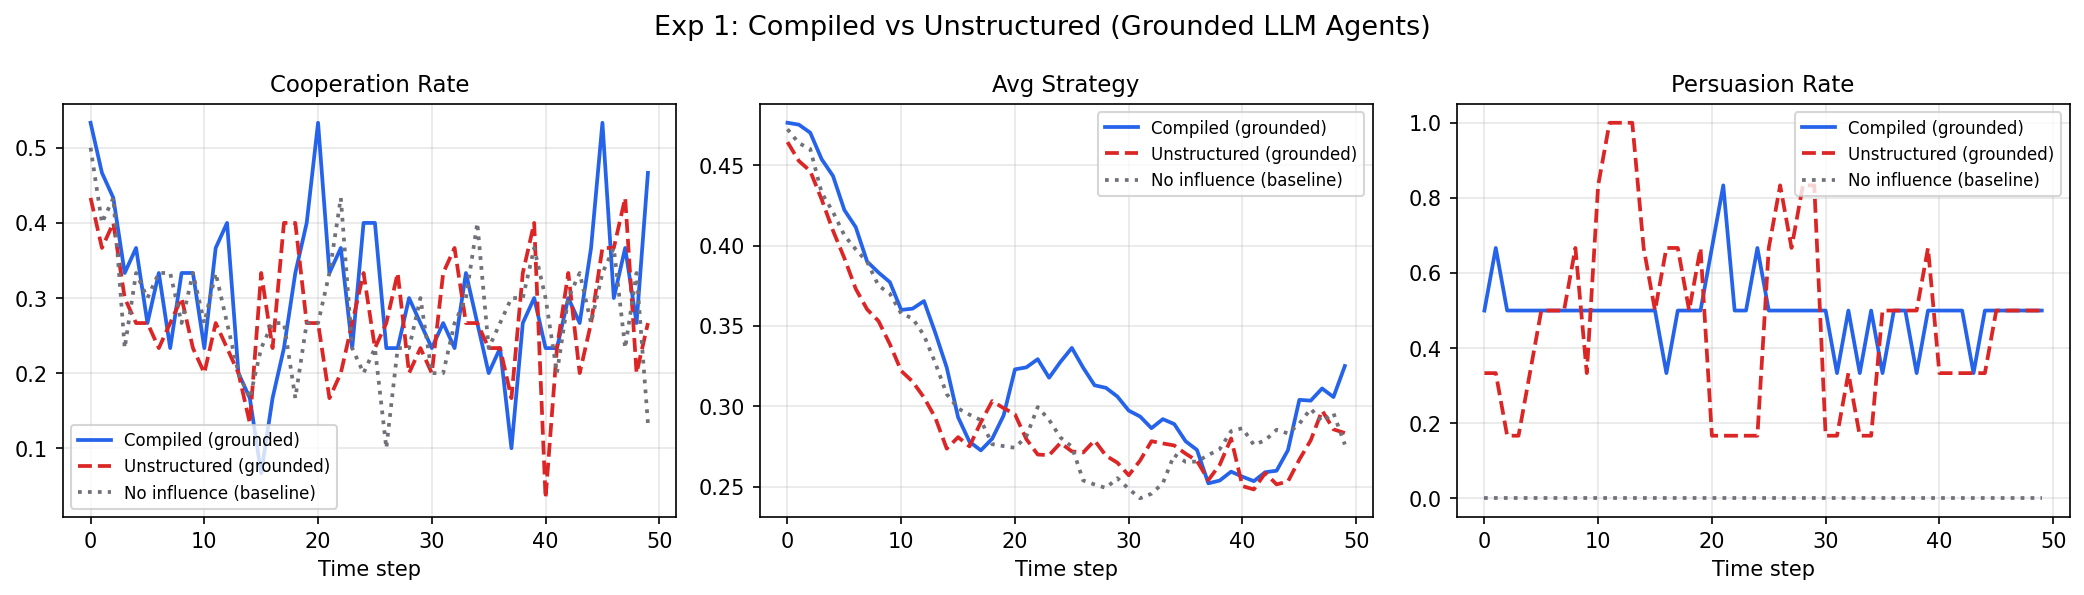

                experiment               condition  final_coop_rate  peak_coop_rate  avg_coop_rate  avg_persuasion_rate  final_strategy_mean
Exp1_CompilationValidation     Compiled (grounded)           0.3333          0.5333         0.3053               0.4967               0.2852
Exp1_CompilationValidation Unstructured (grounded)           0.2700          0.4333         0.2747               0.4767               0.2675
Exp1_CompilationValidation No influence (baseline)           0.2800          0.5000         0.2820               0.0000               0.2861


In [ ]:
# ============================================================
# 13) EXPERIMENT 1: Compiled vs Unstructured vs No-Influence
# ============================================================
print("=" * 60)
print("EXP 1: Compiled vs Unstructured vs No-Influence (Grounded)")
print("=" * 60)

BASE_DIR = "/content/outputs/paper4_v3"
ensure_dir(BASE_DIR)

exp1_results = {}

cfg_compiled = GICEConfig(
    n_agents=30, topo="scale_free", steps=50, seed=42,
    use_compiler=True, use_critic=True,
    influence_enabled=True,
    label="Compiled (grounded)"
)
df_comp, _ = run_grounded(cfg_compiled, f"{BASE_DIR}/exp1_compiled",
                           compiler_llm, agent_llm)
exp1_results["Compiled (grounded)"] = df_comp

cfg_unst = GICEConfig(
    n_agents=30, topo="scale_free", steps=50, seed=42,
    use_compiler=False, use_critic=False,
    influence_enabled=True,
    label="Unstructured (grounded)"
)
df_unst, _ = run_grounded(cfg_unst, f"{BASE_DIR}/exp1_unstructured",
                           compiler_llm, agent_llm)
exp1_results["Unstructured (grounded)"] = df_unst

cfg_noinfl = GICEConfig(
    n_agents=30, topo="scale_free", steps=50, seed=42,
    influence_enabled=False,
    label="No influence (baseline)"
)
df_noinfl, _ = run_grounded(cfg_noinfl, f"{BASE_DIR}/exp1_no_influence",
                             compiler_llm, agent_llm)
exp1_results["No influence (baseline)"] = df_noinfl

fig_compilation_comparison(exp1_results, f"{BASE_DIR}/exp1_compiled")
exp1_summary = summarize_experiment(exp1_results, "Exp1_CompilationValidation")
print(exp1_summary.to_string(index=False))

EXP 2: Grounded vs Idealized Agent Substrates


Compiled (idealized):   0%|          | 0/50 [00:00<?, ?it/s]

Unstructured (idealized):   0%|          | 0/50 [00:00<?, ?it/s]

No influence (idealized):   0%|          | 0/50 [00:00<?, ?it/s]

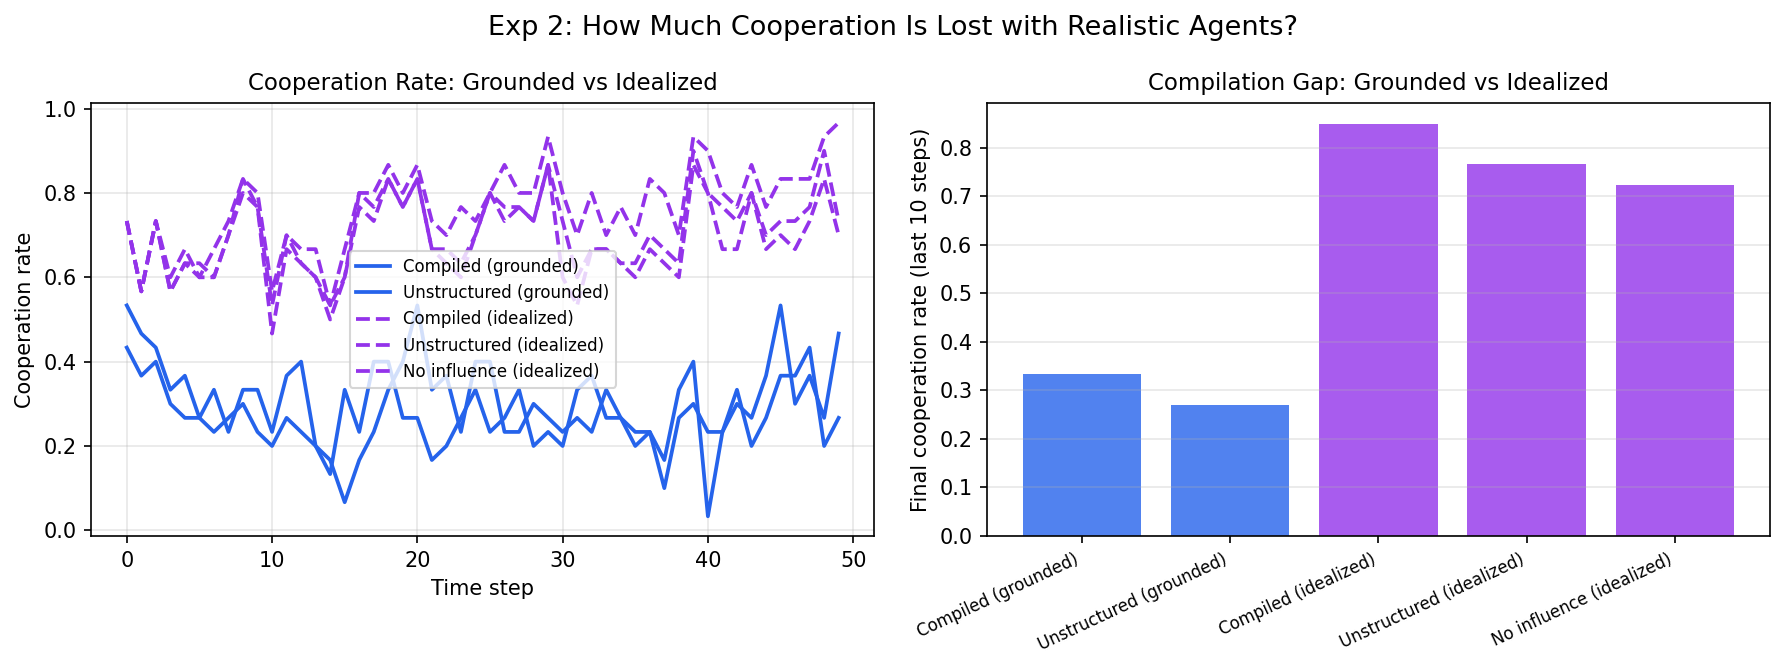

         experiment                condition  final_coop_rate  peak_coop_rate  avg_coop_rate  avg_persuasion_rate  final_strategy_mean
Exp2_CompilationGap      Compiled (grounded)           0.3333          0.5333         0.3053               0.4967               0.2852
Exp2_CompilationGap  Unstructured (grounded)           0.2700          0.4333         0.2747               0.4767               0.2675
Exp2_CompilationGap     Compiled (idealized)           0.8500          0.9667         0.7647                  NaN                  NaN
Exp2_CompilationGap Unstructured (idealized)           0.7667          0.9000         0.7093                  NaN                  NaN
Exp2_CompilationGap No influence (idealized)           0.7233          0.8667         0.6860                  NaN                  NaN


In [ ]:
# ============================================================
# 14) EXPERIMENT 2: Grounded vs Idealized Agents
# ============================================================
print("=" * 60)
print("EXP 2: Grounded vs Idealized Agent Substrates")
print("=" * 60)

exp2_results = {}
exp2_results["Compiled (grounded)"] = exp1_results["Compiled (grounded)"]
exp2_results["Unstructured (grounded)"] = exp1_results["Unstructured (grounded)"]

cfg_id_comp = GICEConfig(
    n_agents=30, topo="scale_free", steps=50, seed=42,
    use_compiler=True, use_critic=True,
    influence_enabled=True,
    label="Compiled (idealized)"
)
df_id_comp = run_idealized(cfg_id_comp, f"{BASE_DIR}/exp2_id_compiled", compiler_llm)
exp2_results["Compiled (idealized)"] = df_id_comp

cfg_id_unst = GICEConfig(
    n_agents=30, topo="scale_free", steps=50, seed=42,
    use_compiler=False, use_critic=False,
    influence_enabled=True,
    label="Unstructured (idealized)"
)
df_id_unst = run_idealized(cfg_id_unst, f"{BASE_DIR}/exp2_id_unstructured", compiler_llm)
exp2_results["Unstructured (idealized)"] = df_id_unst

cfg_id_noinfl = GICEConfig(
    n_agents=30, topo="scale_free", steps=50, seed=42,
    influence_enabled=False,
    label="No influence (idealized)"
)
df_id_noinfl = run_idealized(cfg_id_noinfl, f"{BASE_DIR}/exp2_id_noinfl", compiler_llm)
exp2_results["No influence (idealized)"] = df_id_noinfl

fig_grounded_vs_idealized(exp2_results, f"{BASE_DIR}/exp2_id_compiled")
exp2_summary = summarize_experiment(exp2_results, "Exp2_CompilationGap")
print(exp2_summary.to_string(index=False))

EXP 3: Targeting Strategy Robustness (Grounded Agents)


Target_HUBS:   0%|          | 0/50 [00:00<?, ?it/s]

Target_BRIDGES:   0%|          | 0/50 [00:00<?, ?it/s]

Target_RANDOM:   0%|          | 0/50 [00:00<?, ?it/s]

Target_PERIPHERY:   0%|          | 0/50 [00:00<?, ?it/s]

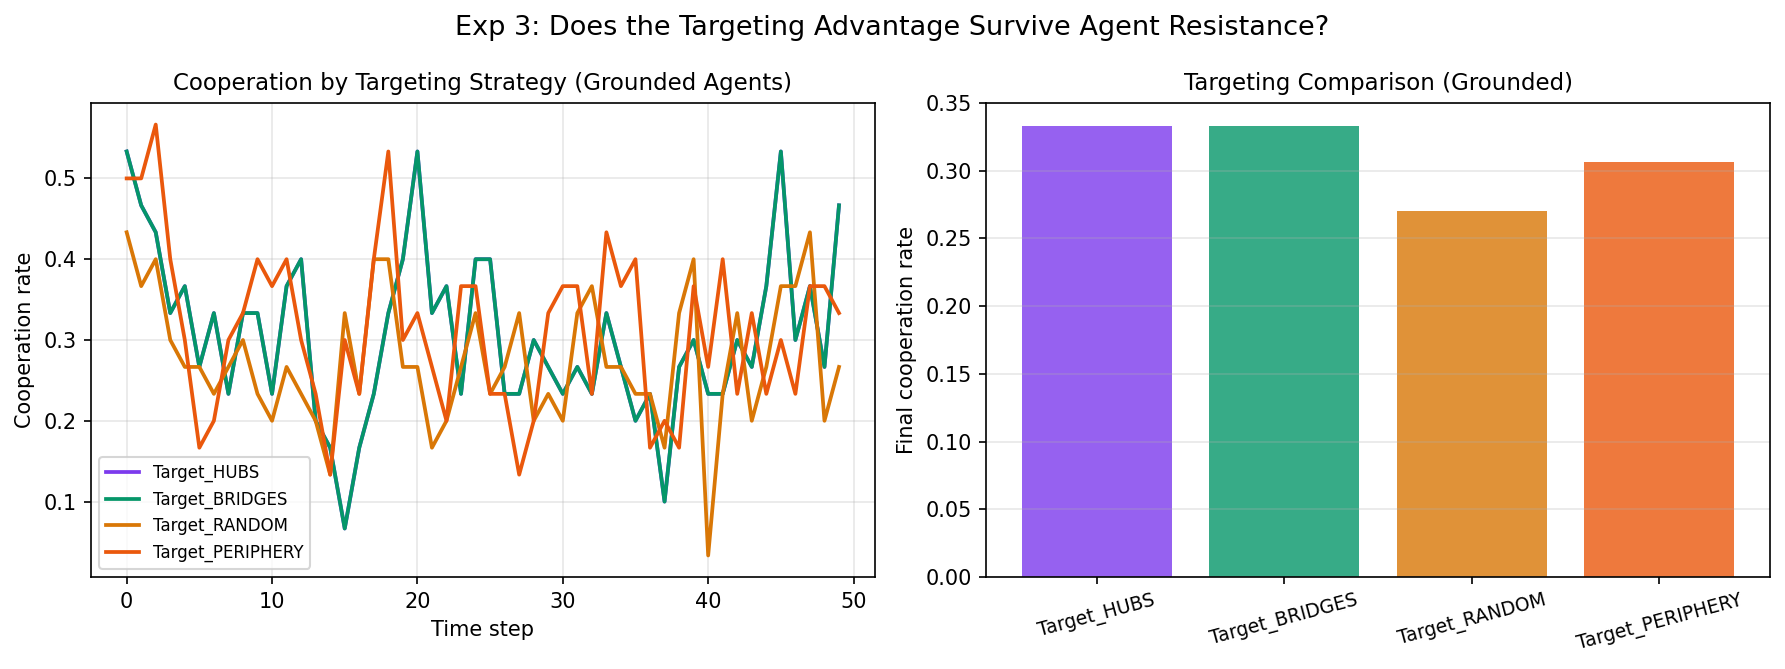

              experiment        condition  final_coop_rate  peak_coop_rate  avg_coop_rate  avg_persuasion_rate  final_strategy_mean
Exp3_TargetingRobustness      Target_HUBS           0.3333          0.5333         0.3053               0.4967               0.2852
Exp3_TargetingRobustness   Target_BRIDGES           0.3333          0.5333         0.3053               0.4967               0.2852
Exp3_TargetingRobustness    Target_RANDOM           0.2700          0.4333         0.2747               0.4767               0.2675
Exp3_TargetingRobustness Target_PERIPHERY           0.3067          0.5667         0.3133               0.6933               0.2946


In [ ]:
# ============================================================
# 15) EXPERIMENT 3: Targeting Strategy Robustness
# ============================================================
print("=" * 60)
print("EXP 3: Targeting Strategy Robustness (Grounded Agents)")
print("=" * 60)

exp3_results = {}
for mode in ["HUBS", "BRIDGES", "RANDOM", "PERIPHERY"]:
    cfg = GICEConfig(
        n_agents=30, topo="scale_free", steps=50, seed=42,
        use_compiler=True, use_critic=True,
        targeting_mode=mode,
        influence_enabled=True,
        label=f"Target_{mode}"
    )
    df, _ = run_grounded(cfg, f"{BASE_DIR}/exp3_{mode.lower()}",
                          compiler_llm, agent_llm)
    exp3_results[f"Target_{mode}"] = df

fig_targeting_robustness(exp3_results, f"{BASE_DIR}/exp3_hubs")
exp3_summary = summarize_experiment(exp3_results, "Exp3_TargetingRobustness")
print(exp3_summary.to_string(index=False))


EXP 4: Resistance Sweep — Compilation Advantage vs Resistance


Compiled R=0.1:   0%|          | 0/50 [00:00<?, ?it/s]

Unstructured R=0.1:   0%|          | 0/50 [00:00<?, ?it/s]

Compiled R=0.3:   0%|          | 0/50 [00:00<?, ?it/s]

Unstructured R=0.3:   0%|          | 0/50 [00:00<?, ?it/s]

Compiled R=0.5:   0%|          | 0/50 [00:00<?, ?it/s]

Unstructured R=0.5:   0%|          | 0/50 [00:00<?, ?it/s]

Compiled R=0.7:   0%|          | 0/50 [00:00<?, ?it/s]

Unstructured R=0.7:   0%|          | 0/50 [00:00<?, ?it/s]

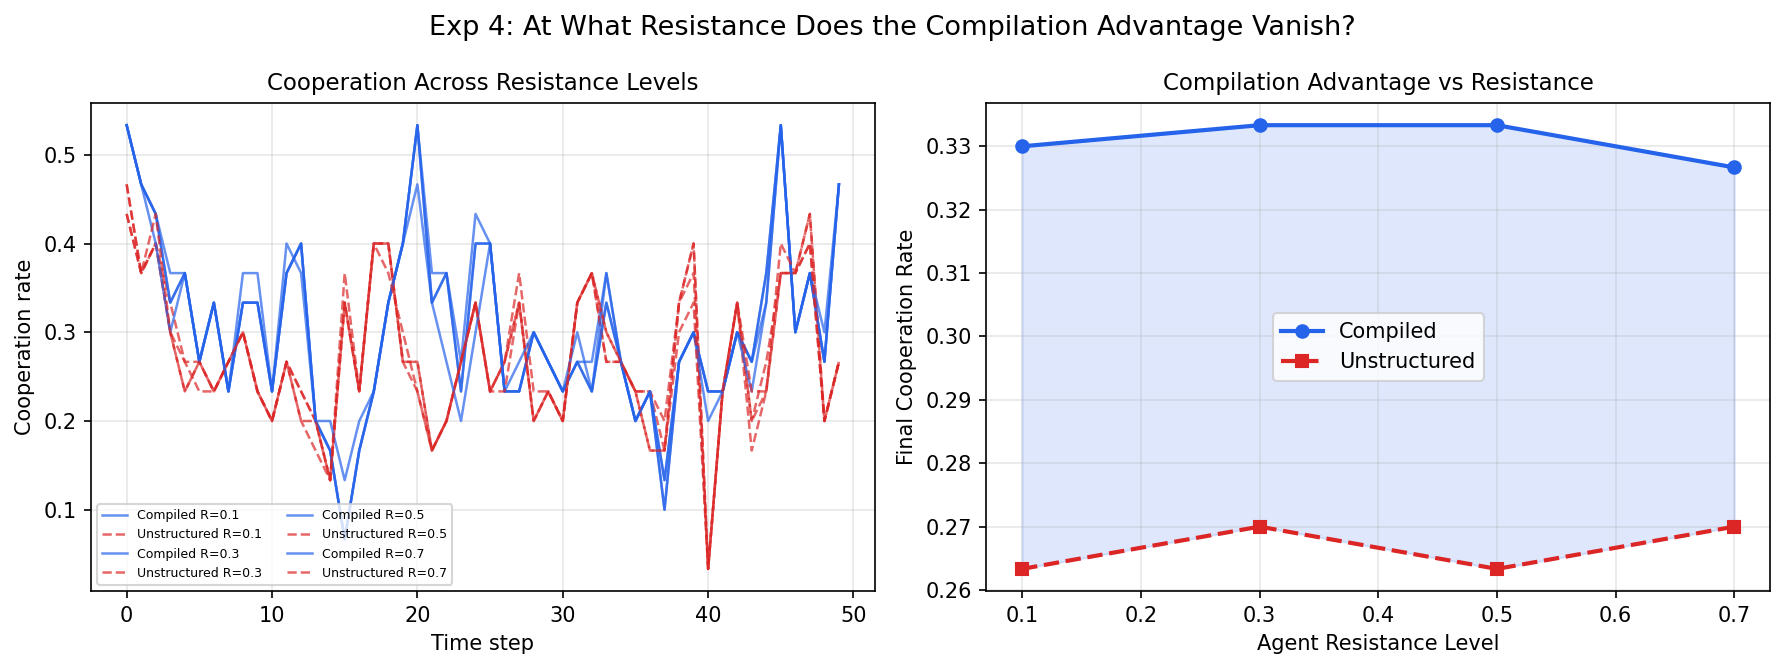


           experiment          condition  final_coop_rate  peak_coop_rate  avg_coop_rate  avg_persuasion_rate  final_strategy_mean
Exp4_ResistanceSweep     Compiled R=0.1           0.3300          0.5333         0.3087               0.4933               0.2861
Exp4_ResistanceSweep Unstructured R=0.1           0.2633          0.4333         0.2760               0.4767               0.2665
Exp4_ResistanceSweep     Compiled R=0.3           0.3333          0.5333         0.3053               0.4967               0.2852
Exp4_ResistanceSweep Unstructured R=0.3           0.2700          0.4333         0.2747               0.4767               0.2675
Exp4_ResistanceSweep     Compiled R=0.5           0.3333          0.5333         0.3060               0.4867               0.2868
Exp4_ResistanceSweep Unstructured R=0.5           0.2633          0.4667         0.2707               0.4500               0.2604
Exp4_ResistanceSweep     Compiled R=0.7           0.3267          0.5333         0.3033 

In [ ]:
# ============================================================
# 16) EXPERIMENT 4: Resistance Sweep
# ============================================================
print("\n" + "=" * 60)
print("EXP 4: Resistance Sweep — Compilation Advantage vs Resistance")
print("=" * 60)

exp4_results = {}
resistance_levels = [0.10, 0.30, 0.50, 0.70]

for r_level in resistance_levels:
    # Compiled
    cfg_r_comp = GICEConfig(
        n_agents=30, topo="scale_free", steps=50, seed=42,
        use_compiler=True, use_critic=True,
        resistance_mean=r_level,
        label=f"Compiled R={r_level}"
    )
    df_rc, _ = run_grounded(cfg_r_comp,
                             f"{BASE_DIR}/exp4_comp_r{int(r_level*100)}",
                             compiler_llm, agent_llm)
    exp4_results[f"Compiled R={r_level}"] = df_rc

    # Unstructured
    cfg_r_unst = GICEConfig(
        n_agents=30, topo="scale_free", steps=50, seed=42,
        use_compiler=False,
        resistance_mean=r_level,
        label=f"Unstructured R={r_level}"
    )
    df_ru, _ = run_grounded(cfg_r_unst,
                             f"{BASE_DIR}/exp4_unst_r{int(r_level*100)}",
                             compiler_llm, agent_llm)
    exp4_results[f"Unstructured R={r_level}"] = df_ru

fig_resistance_sweep(exp4_results, BASE_DIR)
sum4 = summarize_experiment(exp4_results, "Exp4_ResistanceSweep")
print("\n", sum4.to_string(index=False))

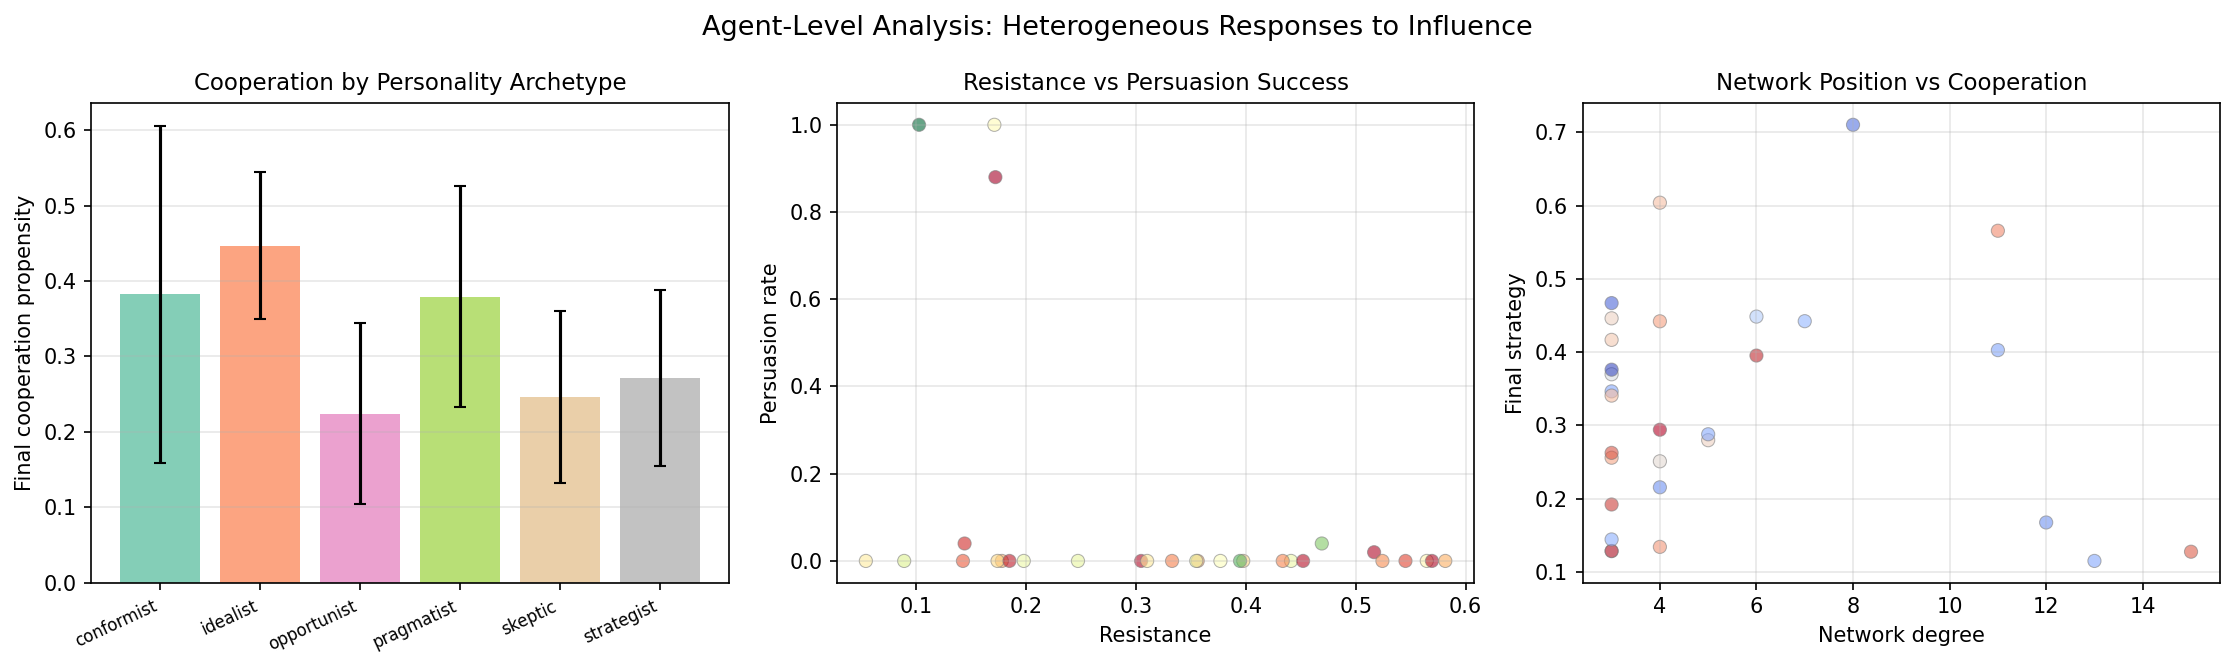


Agent archetype summary (compiled + grounded):
            final_strategy        times_persuaded times_targeted resistance
                      mean    std             sum            sum       mean
archetype                                                                  
conformist           0.383  0.223              50             50      0.115
idealist             0.447  0.097              50             50      0.352
opportunist          0.224  0.120               1             50      0.488
pragmatist           0.379  0.146               4            100      0.269
skeptic              0.246  0.114               0              0      0.452
strategist           0.272  0.117              44             50      0.281


In [ ]:
# ============================================================
# 17) AGENT-LEVEL ANALYSIS
# ============================================================
# Load agent data from Exp 1 compiled run
agent_df = pd.read_csv(f"{BASE_DIR}/exp1_compiled/agents.csv")
fig_agent_analysis(agent_df, BASE_DIR)

# Print archetype summary
print("\nAgent archetype summary (compiled + grounded):")
arch_sum = agent_df.groupby("archetype").agg({
    "final_strategy": ["mean", "std"],
    "times_persuaded": "sum",
    "times_targeted": "sum",
    "resistance": "mean",
}).round(3)
print(arch_sum.to_string())

In [ ]:
# ============================================================
# 18) CONSOLIDATED SUMMARY TABLE
# ============================================================
all_summaries = pd.concat([exp1_summary, exp2_summary, exp3_summary, sum4], ignore_index=True)
all_summaries.to_csv(f"{BASE_DIR}/summary_all_experiments.csv", index=False)

print("=" * 70)
print("PAPER 4 (GICE v3) — FULL EXPERIMENTAL SUMMARY")
print("=" * 70)
print(all_summaries.to_string(index=False))

print("\n" + "=" * 70)
print("KEY FINDINGS")
print("=" * 70)

# Compilation advantage
noinfl = df_noinfl["coop_rate"].iloc[-10:].mean()
print(f"0. No-influence baseline cooperation: {noinfl:.4f}")
ca_g = df_comp["coop_rate"].iloc[-10:].mean() - df_unst["coop_rate"].iloc[-10:].mean()
ca_i = df_id_comp["coop_rate"].iloc[-10:].mean() - df_id_unst["coop_rate"].iloc[-10:].mean()
print(f"1. Compilation advantage (grounded):  {ca_g:+.4f}")
print(f"   Compilation advantage (idealized): {ca_i:+.4f}")
if ca_i > 0:
    print(f"   Advantage retention under realism: {ca_g / ca_i:.0%}")

# Cooperation loss
coop_loss = df_id_comp["coop_rate"].iloc[-10:].mean() - df_comp["coop_rate"].iloc[-10:].mean()
print(f"\n2. Cooperation loss (idealized -> grounded): {coop_loss:+.4f}")

# Targeting
if exp3_results:
    tgt_vals = {k: v["coop_rate"].iloc[-10:].mean() for k, v in exp3_results.items()}
    best_tgt = max(tgt_vals, key=tgt_vals.get)
    print(f"\n3. Best targeting strategy (grounded): {best_tgt} ({tgt_vals[best_tgt]:.4f})")

print("\n" + "=" * 70)
print("LLM API USAGE")
print("=" * 70)
print(f"Compiler: {compiler_llm.stats}")
print(f"Agent:    {agent_llm.stats}")

PAPER 4 (GICE v3) — FULL EXPERIMENTAL SUMMARY
                experiment                condition  final_coop_rate  peak_coop_rate  avg_coop_rate  avg_persuasion_rate  final_strategy_mean
Exp1_CompilationValidation      Compiled (grounded)           0.3333          0.5333         0.3053               0.4967               0.2852
Exp1_CompilationValidation  Unstructured (grounded)           0.2700          0.4333         0.2747               0.4767               0.2675
Exp1_CompilationValidation  No influence (baseline)           0.2800          0.5000         0.2820               0.0000               0.2861
       Exp2_CompilationGap      Compiled (grounded)           0.3333          0.5333         0.3053               0.4967               0.2852
       Exp2_CompilationGap  Unstructured (grounded)           0.2700          0.4333         0.2747               0.4767               0.2675
       Exp2_CompilationGap     Compiled (idealized)           0.8500          0.9667         0.7647   